In [ ]:
!pip install qiskit
!pip install qiskit-aer
!pip install qiskit-ibm-runtime

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit import transpile
from qiskit.visualization import *
from qiskit.circuit.library import QFT, UnitaryGate
from qiskit.quantum_info import Statevector
from numpy import pi
import numpy as np
from matplotlib import pyplot as plt

from qiskit_aer import AerSimulator


In [2]:
# N is the total number of vertices in the 2D grid
L = 8
N = L * L
l = 4 / N 

In [3]:
# Compute coefficients of the coin
a = 2 / (4 + l)
b = 2 * np.sqrt(l) / (4 + l)
c = 2 * l / (4 + l)

In [4]:
C5 = np.array([
    [a - 1,  a,      a,      a,      b],
    [a,      a - 1,  a,      a,      b],
    [a,      a,      a - 1,  a,      b],
    [a,      a,      a,      a - 1,  b],
    [b,      b,      b,      b,      c - 1]
], dtype=complex)

# Embed into an 8x8 matrix for 3 qubits
C8 = np.zeros((8, 8), dtype=complex)
C8[:5, :5] = C5  # top-left block
for i in range(5, 8):
    C8[i, i] = 1

In [5]:
# Creating the gate for Coin
coin_gate = UnitaryGate(C8, label="Coin")

In [6]:
from qiskit.circuit.library import StatePreparation

coin_init = np.zeros(8, dtype=complex)
coin_init[0] = 1 / np.sqrt(4 + l)           # 000
coin_init[1] = 1 / np.sqrt(4 + l)           # 001
coin_init[2] = 1 / np.sqrt(4 + l)           # 010
coin_init[3] = 1 / np.sqrt(4 + l)           # 011
coin_init[4] = np.sqrt(l) / np.sqrt(4 + l)  # 100

coin_prep = StatePreparation(coin_init)

In [7]:
coin = QuantumRegister(3,'coin')
nodeX = QuantumRegister(3,'vertex_X')
nodeY = QuantumRegister(3,'vertex_y')
classR = ClassicalRegister(6,'measure')

one_step = QuantumCircuit(nodeX, nodeY, coin,  classR, name='ONE_STEP')
one_step.append(coin_prep, coin)

one_step.append(coin_gate, coin) # 000 + 001 + 010 + 011 + 100

one_step.draw()


»
vertex_X_0: »
            »
vertex_X_1: »
            »
vertex_X_2: »
            »
vertex_y_0: »
            »
vertex_y_1: »
            »
vertex_y_2: »
            »
    coin_0: »
            »
    coin_1: »
            »
    coin_2: »
            »
 measure: 6/»
            »
«                                                                                 »
«vertex_X_0: ─────────────────────────────────────────────────────────────────────»
«                                                                                 »
«vertex_X_1: ─────────────────────────────────────────────────────────────────────»
«                                                                                 »
«vertex_X_2: ─────────────────────────────────────────────────────────────────────»
«                                                                                 »
«vertex_y_0: ─────────────────────────────────────────────────────────────────────»
«                                                                                 »
«vertex_y_1: ─────────────────────────────────────────────────────────────────────»
«                                                                                 »
«vertex_y_2: ─────────────────────────────────────────────────────────────────────»
«            ┌───────────────────────────────────────────────────────────────────┐»
«    coin_0: ┤0                                                                  ├»
«            │                                                                   │»
«    coin_1: ┤1 State Preparation(0.49614,0.49614,0.49614,0.49614,0.12403,0,0,0) ├»
«            │                                                                   │»
«    coin_2: ┤2                                                                  ├»
«            └───────────────────────────────────────────────────────────────────┘»
« measure: 6/═════════════════════════════════════════════════════════════════════»
«                                                                                 »
«                     
«vertex_X_0: ─────────
«                     
«vertex_X_1: ─────────
«                     
«vertex_X_2: ─────────
«                     
«vertex_y_0: ─────────
«                     
«vertex_y_1: ─────────
«                     
«vertex_y_2: ─────────
«            ┌───────┐
«    coin_0: ┤0      ├
«            │       │
«    coin_1: ┤1 Coin ├
«            │       │
«    coin_2: ┤2      ├
«            └───────┘
« measure: 6/═════════
«

In [8]:
phase_circuit =  QuantumCircuit(6, name=' phase oracle ')
# Mark 000000
phase_circuit.x(0)
phase_circuit.x(1)
phase_circuit.x(2)
phase_circuit.x(3)
phase_circuit.x(4)
phase_circuit.x(5)
phase_circuit.h(5)
phase_circuit.mcx([0,1,2,3,4], 5)
phase_circuit.h(5)
phase_circuit.x(0)
phase_circuit.x(1)
phase_circuit.x(2)
phase_circuit.x(3)
phase_circuit.x(4)
phase_circuit.x(5)
phase_circuit.draw()

┌───┐          ┌───┐     
q_0: ┤ X ├───────■──┤ X ├─────
     ├───┤       │  ├───┤     
q_1: ┤ X ├───────■──┤ X ├─────
     ├───┤       │  ├───┤     
q_2: ┤ X ├───────■──┤ X ├─────
     ├───┤       │  ├───┤     
q_3: ┤ X ├───────■──┤ X ├─────
     ├───┤       │  ├───┤     
q_4: ┤ X ├───────■──┤ X ├─────
     ├───┤┌───┐┌─┴─┐├───┤┌───┐
q_5: ┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├
     └───┘└───┘└───┘└───┘└───┘

In [9]:
def superposition(circuit):
    circuit.h(0)
    circuit.h(1)
    circuit.h(2)
    circuit.h(3)
    circuit.h(4)
    circuit.h(5)
superposition(one_step)

In [10]:
def shift(circuit):
    circuit.x(6)
    circuit.x(7)
    circuit.x(8)  #000 -> 111 + 001 -> 110 + 010 -> 101 + 011 - > 100 + 100-> 011
    circuit.mcx([0,1,6,7,8],2)
    circuit.mcx([0,6,7,8],1)
    circuit.mcx([6,7,8],0)
    circuit.x(6) #001 -> 111 , 010 -> 100, 011-> 101
    circuit.mcx([6,7,8],0)
    circuit.mcx([0,6,7,8],1)
    circuit.mcx([0,1,6,7,8],2)
    circuit.x(6)
    circuit.x(7) #010 - > 111 , 011-> 110
    circuit.mcx([3,4,6,7,8],5)
    circuit.mcx([3,6,7,8],4)
    circuit.mcx([6,7,8],3)
    circuit.x(6) # 011 - > 111
    circuit.mcx([6,7,8],3)
    circuit.mcx([3,6,7,8],4)
    circuit.mcx([3,4,6,7,8],5)
    circuit.x(8)
    circuit.x(6)
    circuit.x(7)
    circuit.mcx([7,8],6)
    circuit.x(7)


In [11]:
import numpy as np
x =  0.922466 * np.sqrt((N)*(np.log2(N)))
#x = 14

In [12]:
for i in range(int(x-1)):
    one_step.append(coin_gate,[6,7,8])
    shift(one_step)
    one_step.append(phase_circuit,[0,1,2,3,4,5])

In [13]:
one_step.measure([0,1,2,3,4,5],[0,1,2,3,4,5])

In [14]:
# one_step.draw()

In [15]:
from qiskit.primitives import StatevectorSampler as Sampler

sampler = Sampler()

job = sampler.run([one_step], shots=1024)

result = job.result()

In [16]:
# First, check what attributes are available in the DataBin
print(dir(result[0].data))

['_FIELDS', '_FIELD_TYPES', '_RESTRICTED_NAMES', '_SHAPE', '__abstractmethods__', '__annotate_func__', '__annotations__', '__annotations_cache__', '__class__', '__class_getitem__', '__contains__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__non_callable_proto_members__', '__parameters__', '__protocol_attrs__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_data', '_is_protocol', '_is_runtime_protocol', '_shape', 'items', 'keys', 'measure', 'ndim', 'shape', 'size', 'values']


In [17]:
counts = result[0].data.measure.get_counts()
print(counts)

{'000000': 983, '010001': 2, '111000': 3, '000001': 4, '001000': 4, '011010': 1, '000010': 1, '011011': 1, '111001': 1, '110111': 2, '000111': 3, '100111': 2, '001101': 1, '000011': 1, '110000': 2, '110101': 1, '000101': 1, '100001': 1, '111010': 2, '100011': 1, '111100': 3, '010100': 1, '001100': 1, '110001': 1, '100010': 1}


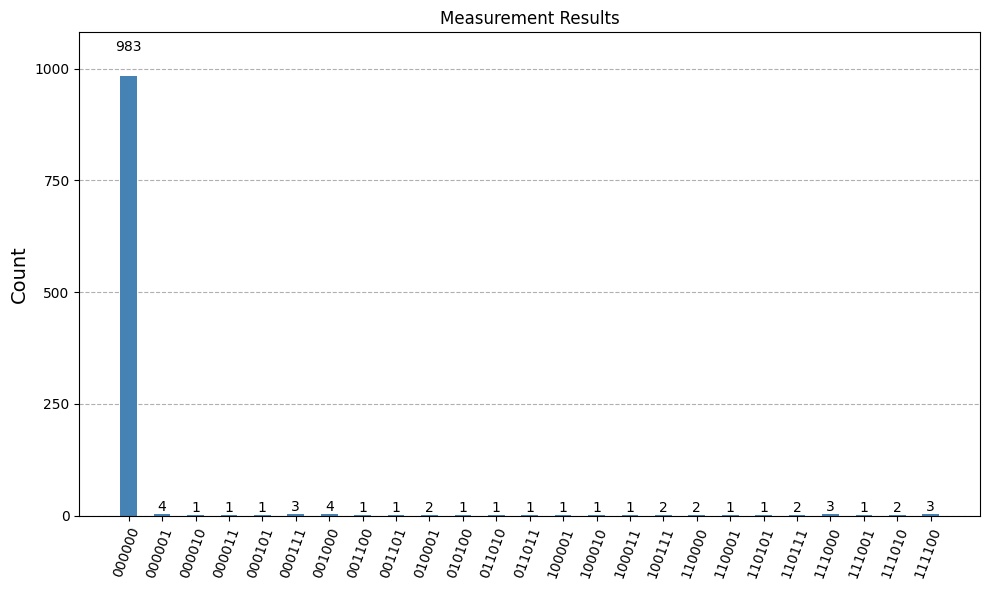

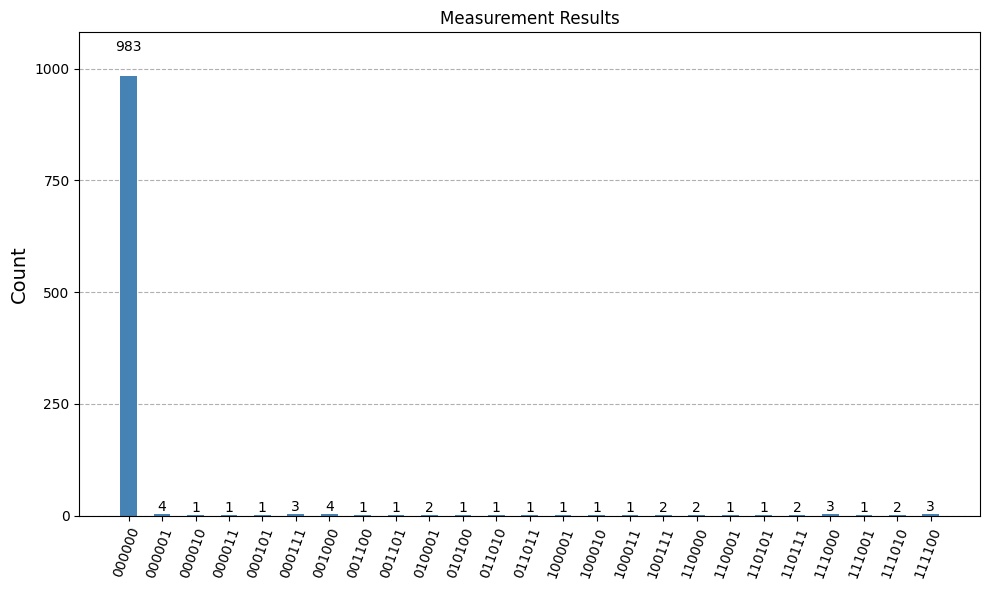

In [18]:
%matplotlib inline
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

fig = plot_histogram(counts, title='Measurement Results', figsize=(10, 6), color='steelblue')
display(fig)

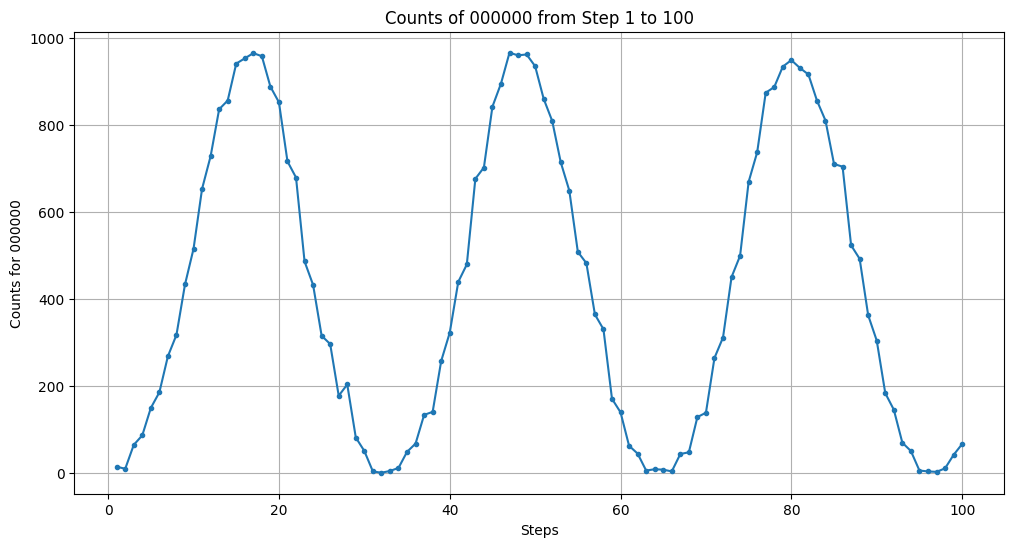

In [19]:
shots = 1000
max_steps = 100
target_state = '000000'

sampler = Sampler()

# Build a fresh circuit for a given number of steps
def build_walk_circuit(num_steps):
    qc = QuantumCircuit(nodeX, nodeY, coin, classR)

    # Initial state preparation
    qc.append(coin_prep, coin)
    superposition(qc)

    # Step 1
    qc.append(coin_gate, coin)
    shift(qc)
    qc.append(phase_circuit, [0, 1, 2, 3, 4, 5])

    # Remaining steps
    for _ in range(num_steps - 1):
        qc.append(coin_gate, [6, 7, 8])
        shift(qc)
        qc.append(phase_circuit, [0, 1, 2, 3, 4, 5])

    # Measure only the first 6 qubits
    qc.measure([0, 1, 2, 3, 4, 5], [0, 1, 2, 3, 4, 5])

    return qc


steps = []
target_counts = []

for step in range(1, max_steps + 1):
    qc = build_walk_circuit(step)

    job = sampler.run([qc], shots=shots)
    result = job.result()

    counts = result[0].data.measure.get_counts()
    count_000000 = counts.get(target_state, 0)

    steps.append(step)
    target_counts.append(count_000000)

    #print(f"Step {step}: {target_state} -> {count_000000}")


# Plot the counts for 000000 from step 1 to 200
plt.figure(figsize=(12, 6))
plt.plot(steps, target_counts, marker='o', markersize=3)
plt.xlabel("Steps")
plt.ylabel(f"Counts for {target_state}")
plt.title(f"Counts of {target_state} from Step 1 to {max_steps}")
plt.grid(True)
plt.show()